# Build 4 — Train AGGIE to Navigate

**COMP 365: Intelligent Agents & Search**

AGGIE is a fictional autonomous safety robot being prepared to assist campus police. Your floor team must build a machine-readable training map and certify AGGIE with BFS, DFS, UCS and A*.

> This is an educational representation—not an official emergency or architectural map.

## How this one notebook is used

1. **Instructor walkthrough:** Run the built-in miniature simulation and compare all four searches.
2. **Student handoff:** Make a personal/team copy of this notebook.
3. **Team build:** Replace the example graph or upload a previously exported floor JSON.
4. **Certification:** Validate, visualize, test, compare and export the completed floor.

## Safety and privacy boundaries

- Use only public, normally accessible areas.
- Do not enter labs, offices, mechanical rooms or restricted areas without permission.
- Do not photograph people, access controls, cameras, alarms or security systems without consent.
- Use approximate coordinates and movement costs.
- Do not test routes in ways that block hallways, stairs or exits. Be respectful.
- Use neutral node names when a location is sensitive.

## Team record — complete before mapping

| Student | Role | Assigned section | Verifiable contribution |
|---|---|---|---|
| TODO | Mapping / data / cost / search / validation / integration / analysis | TODO | TODO |

**Floor:** TODO  
**Team naming convention confirmed:** Yes / No  
**Integrator:** TODO

In [1]:
from collections import deque
from heapq import heappush, heappop
from math import hypot
from copy import deepcopy
import json
import time

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import pandas as pd
import networkx as nx

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15

COLORS = {
    "unseen": "#D9DEE7",
    "frontier": "#FDB927",
    "explored": "#5B9BD5",
    "path": "#2E8B57",
    "start": "#004684",
    "goal": "#E03C31",
}
print("AGGIE navigation tools loaded.")

AGGIE navigation tools loaded.


## Part 1 — Use the common schema

Do not rename schema fields. All floor files must be compatible for later integration.

- Diagonal movement comes naturally from different `x, y` coordinates.
- Use `route_points=[[x, y], ...]` to draw a curved or turning segment between decisions.
- Create a node at any bend where AGGIE must choose an action.
- Give stairs and elevators a shared `connector_id` so floors can be joined later.
- `movement_type` must be `hallway`, `curved_hallway`, `stairs`, or `elevator`.
- Search can optimize `distance`, `travel_time`, or `energy_cost`.

In [2]:
def edge(to, distance, travel_time=None, energy_cost=None, accessible=True,
         movement_type="hallway", route_points=None):
    return {
        "to": to,
        "distance": float(distance),
        "travel_time": float(travel_time if travel_time is not None else distance),
        "energy_cost": float(energy_cost if energy_cost is not None else distance),
        "accessible": bool(accessible),
        "movement_type": movement_type,
        "route_points": route_points or [],
    }

def node(label, kind, x, y, floor=0, neighbors=None, accessible=True, connector_id=None):
    return {
        "label": label,
        "type": kind,
        "position": [float(x), float(y)],
        "floor": int(floor),
        "accessible": bool(accessible),
        "connector_id": connector_id,
        "neighbors": neighbors or [],
    }

def connect_nodes(graph, a, b, distance, travel_time=None, energy_cost=None,
                  accessible=True, movement_type="hallway", route_points=None):
    """Create a two-way connection; reverse geometry is generated automatically."""
    graph[a]["neighbors"].append(edge(
        b, distance, travel_time, energy_cost, accessible, movement_type, route_points))
    graph[b]["neighbors"].append(edge(
        a, distance, travel_time, energy_cost, accessible, movement_type,
        list(reversed(route_points or []))))

def validate_graph(graph):
    issues = []
    for node_id, data in graph.items():
        if "position" not in data or len(data["position"]) != 2:
            issues.append(f"{node_id}: missing 2D position")
        if data.get("type") in {"stairs", "elevator"} and not data.get("connector_id"):
            issues.append(f"{node_id}: vertical connector needs connector_id")
        for e in data.get("neighbors", []):
            if e["to"] not in graph:
                issues.append(f"{node_id}: neighbor {e['to']} does not exist")
            if e.get("distance", 0) < 0 or e.get("travel_time", 0) < 0:
                issues.append(f"{node_id} -> {e['to']}: negative cost")
            if e.get("movement_type") not in {"hallway", "curved_hallway", "stairs", "elevator"}:
                issues.append(f"{node_id} -> {e['to']}: unsupported movement_type")
            points = e.get("route_points", [])
            if any(not isinstance(p, (list, tuple)) or len(p) != 2 for p in points):
                issues.append(f"{node_id} -> {e['to']}: route_points must be [x, y] pairs")
    return issues

def graph_summary(graph):
    directed_edges = sum(len(v.get("neighbors", [])) for v in graph.values())
    return {"nodes": len(graph), "directed_edges": directed_edges,
            "types": sorted({v["type"] for v in graph.values()})}

## Part 2 — Replace the miniature example with your floor

### Required node identifiers

Use `F<floor>_<LOCATION>`, such as `F4_HALL_EAST_01`.

The built-in 11-node fictional floor is the instructor walkthrough. It includes alternate routes, diagonal geometry, a curved segment, stairs, an elevator, accessibility flags, and multiple costs.

After the walkthrough, make a copy. Replace its metadata and graph with your assigned floor. Tuesday’s checkpoint requires **at least five connected nodes**; the final submission should contain the team’s complete educational representation.

In [3]:
FLOOR_METADATA = {
    "building": "Fictional Engineering Building",
    "floor": 4,
    "team": "Instructor Simulation",
    "coordinate_system": "approximate_xy_units",
    "cost_unit": "estimated_distance_units",
    "educational_use_only": True,
}

FLOOR_MAP = {
    "F4_ELEVATOR": node("Elevator", "elevator", 0, 2, floor=4, connector_id="ELEVATOR_MAIN"),
    "F4_HALL_W": node("West Hall", "intersection", 2, 2, floor=4),
    "F4_LAB_A": node("Robotics Lab", "lab", 2, 4, floor=4),
    "F4_STAIRS_W": node("West Stairs", "stairs", 2, 0, floor=4, accessible=False, connector_id="STAIRS_W"),
    "F4_HALL_C": node("Central Hall", "intersection", 5, 2, floor=4),
    "F4_CLASS": node("Classroom", "classroom", 5, 4, floor=4),
    "F4_LOUNGE": node("Student Lounge", "common", 5, 0, floor=4),
    "F4_HALL_E": node("East Hall", "intersection", 8, 2, floor=4),
    "F4_OFFICE": node("Dean Suite", "office", 8, 4, floor=4),
    "F4_STAIRS_E": node("East Stairs", "stairs", 8, 0, floor=4, accessible=False, connector_id="STAIRS_E"),
    "F4_EXIT": node("Skybridge Exit", "exit", 10, 2, floor=4),
}

def connect(a, b, distance, travel_time=None, energy_cost=None, accessible=True,
            movement_type="hallway", route_points=None):
    FLOOR_MAP[a]["neighbors"].append(edge(
        b, distance, travel_time, energy_cost, accessible, movement_type, route_points))
    FLOOR_MAP[b]["neighbors"].append(edge(
        a, distance, travel_time, energy_cost, accessible, movement_type,
        list(reversed(route_points or []))))

connect("F4_ELEVATOR", "F4_HALL_W", 2)
connect("F4_HALL_W", "F4_LAB_A", 2)
connect("F4_HALL_W", "F4_STAIRS_W", 2, energy_cost=5, accessible=False, movement_type="stairs")
connect("F4_HALL_W", "F4_HALL_C", 5)
connect("F4_LAB_A", "F4_CLASS", 4.5, movement_type="curved_hallway",
        route_points=[[3.0, 4.8], [4.2, 4.7]])
connect("F4_HALL_C", "F4_CLASS", 2)
connect("F4_HALL_C", "F4_LOUNGE", 2)
connect("F4_HALL_C", "F4_HALL_E", 3)
connect("F4_CLASS", "F4_OFFICE", 7)
connect("F4_LOUNGE", "F4_STAIRS_E", 4, energy_cost=8, accessible=False, movement_type="stairs")
connect("F4_HALL_E", "F4_OFFICE", 2)
connect("F4_HALL_E", "F4_STAIRS_E", 2, energy_cost=5, accessible=False, movement_type="stairs")
connect("F4_HALL_E", "F4_EXIT", 2)

print(FLOOR_METADATA)
print(graph_summary(FLOOR_MAP))
issues = validate_graph(FLOOR_MAP)
print("Validation:", "PASS" if not issues else issues)

{'building': 'Fictional Engineering Building', 'floor': 4, 'team': 'Instructor Simulation', 'coordinate_system': 'approximate_xy_units', 'cost_unit': 'estimated_distance_units', 'educational_use_only': True}
{'nodes': 11, 'directed_edges': 26, 'types': ['classroom', 'common', 'elevator', 'exit', 'intersection', 'lab', 'office', 'stairs']}
Validation: PASS


### Team handoff TODO

Before editing the demonstration graph:

1. Make a copy of this notebook.
2. **Change `FLOOR_METADATA` to your assigned floor and team.**
3. Replace the fictional nodes and connections with the team graph.
4. Preserve the schema, identifier convention, and connector IDs.

Alternatively, use the next section to upload an exported team JSON and resume.

## Part 3 — Save, upload, and resume

Run the next cell after the schema and example-map cells. Loading a JSON file replaces the active `FLOOR_METADATA` and `FLOOR_MAP`, so every later visualization and search uses the uploaded data.

The loader accepts either a normal Python file path or a Colab upload. It validates the bundle before replacing the active map.

In [4]:
def load_floor_bundle(bundle):
    """Validate an imported dictionary without altering active work on failure."""
    if not isinstance(bundle, dict) or "metadata" not in bundle or "nodes" not in bundle:
        raise ValueError("Expected a JSON object with 'metadata' and 'nodes'.")
    candidate_metadata = bundle["metadata"]
    candidate_map = bundle["nodes"]
    issues = validate_graph(candidate_map)
    if issues:
        raise ValueError("Imported map failed validation:\n- " + "\n- ".join(issues))
    print(f"Ready: Floor {candidate_metadata.get('floor')} with {len(candidate_map)} nodes.")
    return candidate_metadata, candidate_map

def load_floor_map(filename):
    with open(filename, "r", encoding="utf-8") as f:
        bundle = json.load(f)
    return load_floor_bundle(bundle)

def upload_floor_map_colab():
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError("Colab upload is available only in Google Colab. Use load_floor_map(path) locally.") from exc
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Upload exactly one floor JSON file.")
    filename, raw = next(iter(uploaded.items()))
    print("Uploaded:", filename)
    return load_floor_bundle(json.loads(raw.decode("utf-8")))

# CHOOSE ONE RESUME OPTION, then remove the leading # symbols:
# FLOOR_METADATA, FLOOR_MAP = load_floor_map("floor_4_map.json")
# FLOOR_METADATA, FLOOR_MAP = upload_floor_map_colab()

print("Current active map:", FLOOR_METADATA["team"], "| nodes:", len(FLOOR_MAP))

Current active map: Instructor Simulation | nodes: 11


## Part 4 — Validate before searching

A visually convincing map may still be unusable to an agent. Fix every validation issue before running missions.

In [5]:
issues = validate_graph(FLOOR_MAP)
print(graph_summary(FLOOR_MAP))
print("PASS" if not issues else "\n".join(issues))
assert not issues, "Fix graph issues before continuing."

{'nodes': 11, 'directed_edges': 26, 'types': ['classroom', 'common', 'elevator', 'exit', 'intersection', 'lab', 'office', 'stairs']}
PASS


### Human validation checklist

- [ ] Every node represents a recognizable public location or decision point.
- [ ] Every edge represents a legal direct movement.
- [ ] Reverse movement is included when physically possible.
- [ ] Costs use the same approximate unit.
- [ ] Coordinates are approximate and internally consistent.
- [ ] Stairs and inaccessible edges are flagged.
- [ ] Connector names follow the class convention.
- [ ] Another team member reviewed the section.

## Part 5 — Provided search engine

Read the implementations and annotate at least one line in each algorithm that controls which state is explored next. You may modify or extend the algorithms, but preserve the result format.

In [6]:
def reconstruct(parent, goal):
    path = [goal]
    while parent[path[-1]] is not None:
        path.append(parent[path[-1]])
    return list(reversed(path))

def path_cost(graph, path, cost_key="distance"):
    total = 0.0
    for a, b in zip(path, path[1:]):
        match = next(e for e in graph[a]["neighbors"] if e["to"] == b)
        total += float(match[cost_key])
    return total

def finish(name, graph, goal, parent, explored, frames, cost_key, started):
    found = goal in parent
    path = reconstruct(parent, goal) if found else []
    return {
        "algorithm": name,
        "found": found,
        "path": path,
        "path_cost": path_cost(graph, path, cost_key) if found else float("inf"),
        "nodes_explored": len(explored),
        "exploration_order": explored,
        "frames": frames,
        "runtime_ms": (time.perf_counter() - started) * 1000,
    }

def allowed_edges(graph, current, accessible_only):
    for e in graph[current]["neighbors"]:
        if accessible_only and not e.get("accessible", True):
            continue
        yield e

def bfs(graph, start, goal, cost_key="distance", accessible_only=False):
    started = time.perf_counter(); frontier = deque([start])
    parent = {start: None}; explored = []; frames = []
    while frontier:
        current = frontier.popleft(); explored.append(current)
        frames.append({"current": current, "explored": explored.copy(), "frontier": list(frontier)})
        if current == goal: break
        for e in allowed_edges(graph, current, accessible_only):
            nxt = e["to"]
            if nxt not in parent:
                parent[nxt] = current; frontier.append(nxt)
    return finish("BFS", graph, goal, parent, explored, frames, cost_key, started)

def dfs(graph, start, goal, cost_key="distance", accessible_only=False):
    started = time.perf_counter(); frontier = [start]
    parent = {start: None}; explored = []; frames = []
    while frontier:
        current = frontier.pop()
        if current in explored: continue
        explored.append(current)
        frames.append({"current": current, "explored": explored.copy(), "frontier": frontier.copy()})
        if current == goal: break
        edges = list(allowed_edges(graph, current, accessible_only))
        for e in reversed(edges):
            nxt = e["to"]
            if nxt not in parent:
                parent[nxt] = current; frontier.append(nxt)
    return finish("DFS", graph, goal, parent, explored, frames, cost_key, started)

def ucs(graph, start, goal, cost_key="distance", accessible_only=False):
    started = time.perf_counter(); frontier = [(0.0, start)]
    parent = {start: None}; best = {start: 0.0}; explored = []; frames = []
    while frontier:
        g, current = heappop(frontier)
        if g != best[current]: continue
        explored.append(current)
        frames.append({"current": current, "explored": explored.copy(), "frontier": [n for _, n in frontier]})
        if current == goal: break
        for e in allowed_edges(graph, current, accessible_only):
            nxt = e["to"]; new_g = g + e[cost_key]
            if new_g < best.get(nxt, float("inf")):
                best[nxt] = new_g; parent[nxt] = current; heappush(frontier, (new_g, nxt))
    return finish("UCS", graph, goal, parent, explored, frames, cost_key, started)

def straight_line_heuristic(graph, node_id, goal_id, floor_change_cost=12.0):
    x1, y1 = graph[node_id]["position"]; x2, y2 = graph[goal_id]["position"]
    planar = hypot(x2 - x1, y2 - y1)
    vertical = floor_change_cost * abs(graph[node_id].get("floor", 0) - graph[goal_id].get("floor", 0))
    return hypot(planar, vertical)

def astar(graph, start, goal, cost_key="distance", accessible_only=False, heuristic=straight_line_heuristic):
    started = time.perf_counter(); frontier = [(heuristic(graph, start, goal), 0.0, start)]
    parent = {start: None}; best = {start: 0.0}; explored = []; frames = []
    while frontier:
        _, g, current = heappop(frontier)
        if g != best[current]: continue
        explored.append(current)
        frames.append({"current": current, "explored": explored.copy(), "frontier": [n for _, _, n in frontier]})
        if current == goal: break
        for e in allowed_edges(graph, current, accessible_only):
            nxt = e["to"]; new_g = g + e[cost_key]
            if new_g < best.get(nxt, float("inf")):
                best[nxt] = new_g; parent[nxt] = current
                heappush(frontier, (new_g + heuristic(graph, nxt, goal), new_g, nxt))
    return finish("A*", graph, goal, parent, explored, frames, cost_key, started)

SEARCHERS = {"BFS": bfs, "DFS": dfs, "UCS": ucs, "A*": astar}

In [7]:
def nx_graph(graph):
    G = nx.DiGraph()
    for n, data in graph.items():
        G.add_node(n)
        for e in data["neighbors"]:
            G.add_edge(n, e["to"], weight=e["distance"])
    return G

EDGE_STYLE = {
    "hallway": {"color": "#9AA4B2", "linestyle": "-", "linewidth": 2.0},
    "curved_hallway": {"color": "#6C7A89", "linestyle": "-", "linewidth": 2.4},
    "stairs": {"color": "#FDB927", "linestyle": "--", "linewidth": 3.0},
    "elevator": {"color": "#2E8B57", "linestyle": ":", "linewidth": 3.5},
}

def edge_coordinates(graph, a, edge_data):
    b = edge_data["to"]
    return [graph[a]["position"], *edge_data.get("route_points", []), graph[b]["position"]]

def draw_movement_edges(graph, ax, highlighted_path=None):
    highlighted = set(zip(highlighted_path or [], (highlighted_path or [])[1:]))
    drawn_pairs = set()
    for a, data in graph.items():
        for e in data["neighbors"]:
            b = e["to"]
            pair = tuple(sorted((a, b)))
            if pair in drawn_pairs: continue
            drawn_pairs.add(pair)
            pts = edge_coordinates(graph, a, e)
            xs, ys = zip(*pts)
            style = dict(EDGE_STYLE.get(e.get("movement_type", "hallway"), EDGE_STYLE["hallway"]))
            if (a, b) in highlighted or (b, a) in highlighted:
                style = {"color": COLORS["path"], "linestyle": "-", "linewidth": 5.0}
            ax.plot(xs, ys, zorder=1, **style)

def draw_floor(graph, title="AGGIE floor map", path=None, ax=None):
    ax = ax or plt.gca(); G = nx_graph(graph)
    pos = {n: tuple(data["position"]) for n, data in graph.items()}
    draw_movement_edges(graph, ax, path)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#D9DEE7", edgecolors="#004684", node_size=1050)
    labels = {n: data["label"] for n, data in graph.items()}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)
    from matplotlib.lines import Line2D
    legend = [Line2D([0], [0], label=k.replace("_", " ").title(), **v) for k, v in EDGE_STYLE.items()]
    ax.legend(handles=legend, loc="upper left", frameon=False, fontsize=8)
    ax.set_title(title); ax.axis("off")
    return ax

def animate_search(graph, result, start, goal, interval=650):
    G = nx_graph(graph); pos = {n: tuple(d["position"]) for n, d in graph.items()}
    labels = {n: d["label"] for n, d in graph.items()}
    frames = result["frames"] + ([{"current": goal, "explored": result["exploration_order"], "frontier": []}] if result["found"] else [])
    fig, ax = plt.subplots(figsize=(10, 6))
    def update(i):
        ax.clear(); frame = frames[i]
        colors = []
        for n in G.nodes:
            if n == start: c = COLORS["start"]
            elif n == goal: c = COLORS["goal"]
            elif n == frame["current"]: c = COLORS["frontier"]
            elif n in frame["explored"]: c = COLORS["explored"]
            elif n in frame["frontier"]: c = COLORS["frontier"]
            else: c = COLORS["unseen"]
            colors.append(c)
        final_path = result["path"] if i == len(frames) - 1 and result["found"] else None
        draw_movement_edges(graph, ax, final_path)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, edgecolors="white", node_size=1150)
        nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8)
        ax.set_title(f"{result['algorithm']} | step {i+1}/{len(frames)} | current: {labels[frame['current']]}")
        ax.axis("off")
    animation = FuncAnimation(fig, update, frames=len(frames), interval=interval, repeat=False)
    plt.close(fig)
    return HTML(animation.to_jshtml())

def compare_searches(graph, start, goal, cost_key="distance", accessible_only=False):
    results = [fn(graph, start, goal, cost_key, accessible_only) for fn in SEARCHERS.values()]
    table = pd.DataFrame([{
        "Algorithm": r["algorithm"], "Found": r["found"],
        "Path": " → ".join(graph[n]["label"] for n in r["path"]),
        "Cost": round(r["path_cost"], 2), "Nodes explored": r["nodes_explored"],
        "Runtime (ms)": round(r["runtime_ms"], 3),
    } for r in results])
    return results, table

## Part 6 — Inspect your graph

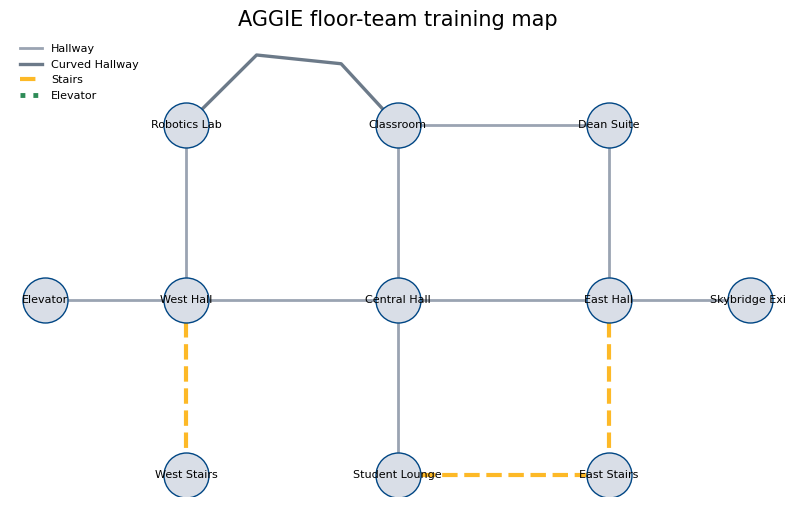

In [8]:
draw_floor(FLOOR_MAP, "AGGIE floor-team training map")
plt.show()

## Part 7 — Choose a common certification mission

All four algorithms must use the same start, goal, cost key, and accessibility setting for the comparison.

In [9]:
# The built-in walkthrough uses Elevator → Dean Suite.
# TODO 3: Replace these with meaningful nodes after adding or loading your team map.
START = "F4_ELEVATOR" if "F4_ELEVATOR" in FLOOR_MAP else next(iter(FLOOR_MAP))
GOAL = "F4_OFFICE" if "F4_OFFICE" in FLOOR_MAP else list(FLOOR_MAP)[-1]
COST_KEY = "distance"
ACCESSIBLE_ONLY = False

print("Mission:", FLOOR_MAP[START]["label"], "→", FLOOR_MAP[GOAL]["label"])

Mission: Elevator → Dean Suite


## Part 8 — BFS only

In [10]:
bfs_result = bfs(FLOOR_MAP, START, GOAL, COST_KEY, ACCESSIBLE_ONLY)
display({k: v for k, v in bfs_result.items() if k != "frames"})
display(animate_search(FLOOR_MAP, bfs_result, START, GOAL))

{'algorithm': 'BFS',
 'found': True,
 'path': ['F4_ELEVATOR', 'F4_HALL_W', 'F4_LAB_A', 'F4_CLASS', 'F4_OFFICE'],
 'path_cost': 15.5,
 'nodes_explored': 9,
 'exploration_order': ['F4_ELEVATOR',
  'F4_HALL_W',
  'F4_LAB_A',
  'F4_STAIRS_W',
  'F4_HALL_C',
  'F4_CLASS',
  'F4_LOUNGE',
  'F4_HALL_E',
  'F4_OFFICE'],
 'runtime_ms': 0.05186999999295949}

**TODO 4 — Explain:** Why did BFS explore nodes in this order? Did its path have the fewest transitions?

## Part 9 — DFS only

In [11]:
dfs_result = dfs(FLOOR_MAP, START, GOAL, COST_KEY, ACCESSIBLE_ONLY)
display({k: v for k, v in dfs_result.items() if k != "frames"})
display(animate_search(FLOOR_MAP, dfs_result, START, GOAL))

{'algorithm': 'DFS',
 'found': True,
 'path': ['F4_ELEVATOR', 'F4_HALL_W', 'F4_LAB_A', 'F4_CLASS', 'F4_OFFICE'],
 'path_cost': 15.5,
 'nodes_explored': 5,
 'exploration_order': ['F4_ELEVATOR',
  'F4_HALL_W',
  'F4_LAB_A',
  'F4_CLASS',
  'F4_OFFICE'],
 'runtime_ms': 0.03284000001713139}

**TODO 5 — Explain:** How did neighbor order affect DFS? Was the returned route reasonable?

## Part 10 — UCS only

In [12]:
ucs_result = ucs(FLOOR_MAP, START, GOAL, COST_KEY, ACCESSIBLE_ONLY)
display({k: v for k, v in ucs_result.items() if k != "frames"})
display(animate_search(FLOOR_MAP, ucs_result, START, GOAL))

{'algorithm': 'UCS',
 'found': True,
 'path': ['F4_ELEVATOR', 'F4_HALL_W', 'F4_HALL_C', 'F4_HALL_E', 'F4_OFFICE'],
 'path_cost': 12.0,
 'nodes_explored': 10,
 'exploration_order': ['F4_ELEVATOR',
  'F4_HALL_W',
  'F4_LAB_A',
  'F4_STAIRS_W',
  'F4_HALL_C',
  'F4_CLASS',
  'F4_LOUNGE',
  'F4_HALL_E',
  'F4_EXIT',
  'F4_OFFICE'],
 'runtime_ms': 0.0636500000155138}

**TODO 6 — Explain:** What accumulated costs caused UCS to prefer its route?

## Part 11 — A* only

In [13]:
astar_result = astar(FLOOR_MAP, START, GOAL, COST_KEY, ACCESSIBLE_ONLY)
display({k: v for k, v in astar_result.items() if k != "frames"})
display(animate_search(FLOOR_MAP, astar_result, START, GOAL))

{'algorithm': 'A*',
 'found': True,
 'path': ['F4_ELEVATOR', 'F4_HALL_W', 'F4_HALL_C', 'F4_HALL_E', 'F4_OFFICE'],
 'path_cost': 12.0,
 'nodes_explored': 8,
 'exploration_order': ['F4_ELEVATOR',
  'F4_HALL_W',
  'F4_LAB_A',
  'F4_HALL_C',
  'F4_STAIRS_W',
  'F4_CLASS',
  'F4_HALL_E',
  'F4_OFFICE'],
 'runtime_ms': 0.08492999995723949}

**TODO 7 — Explain:** How does the coordinate-based heuristic estimate the remaining distance? Is it reasonable for your map?

## Part 12 — Compare all four

In [14]:
results, comparison = compare_searches(FLOOR_MAP, START, GOAL, COST_KEY, ACCESSIBLE_ONLY)
display(comparison)

,Algorithm,Found,Path,Cost,Nodes explored,Runtime (ms)
0,BFS,True,Elevator → West Hall → Robotics Lab → Classroo...,15.5,9,0.045
1,DFS,True,Elevator → West Hall → Robotics Lab → Classroo...,15.5,5,0.020
2,UCS,True,Elevator → West Hall → Central Hall → East Hal...,12.0,10,0.043
3,A*,True,Elevator → West Hall → Central Hall → East Hal...,12.0,8,0.047


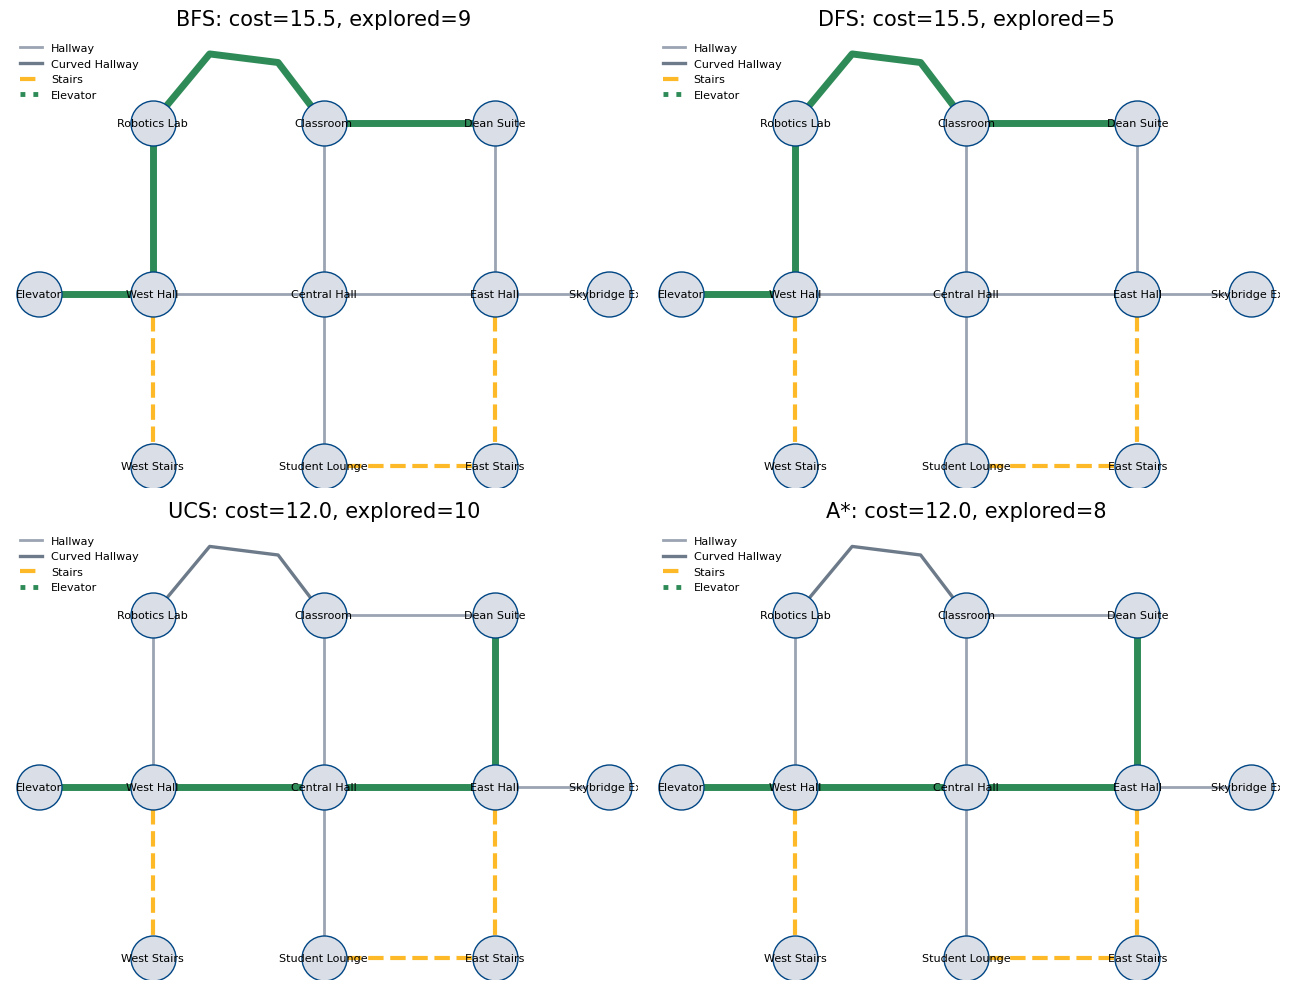

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, result in zip(axes.flat, results):
    draw_floor(FLOOR_MAP, f"{result['algorithm']}: cost={result['path_cost']:.1f}, explored={result['nodes_explored']}", result["path"], ax)
plt.tight_layout(); plt.show()

### TODO 8 — Team recommendation

Which algorithm should AGGIE use for this mission? Support the recommendation with the comparison table. Discuss path quality, cost, explored nodes and assumptions. Do not claim one algorithm is universally best. You should try all routes with the different algorithms.

## Part 13 — Accessibility certification

Choose a start and goal for which accessibility matters. Run all four algorithms with `accessible_only=True`. If your floor has no relevant edge, explain what accessibility information your representation is missing.

In [16]:
# TODO 9: Select meaningful nodes.
ACCESS_START = START
ACCESS_GOAL = GOAL
accessible_results, accessible_table = compare_searches(
    FLOOR_MAP, ACCESS_START, ACCESS_GOAL, COST_KEY, accessible_only=True
)
display(accessible_table)

,Algorithm,Found,Path,Cost,Nodes explored,Runtime (ms)
0,BFS,True,Elevator → West Hall → Robotics Lab → Classroo...,15.5,8,0.047
1,DFS,True,Elevator → West Hall → Robotics Lab → Classroo...,15.5,5,0.019
2,UCS,True,Elevator → West Hall → Central Hall → East Hal...,12.0,9,0.034
3,A*,True,Elevator → West Hall → Central Hall → East Hal...,12.0,7,0.037


## Part 14 — Export your certified floor

The filename and schema allow the four floors to be joined later.

In [17]:
if FLOOR_METADATA["floor"] not in {1, 2, 3, 4}:
    print("TEMPLATE MODE: Set the assigned floor to 1–4 before exporting.")
elif validate_graph(FLOOR_MAP):
    print("Resolve validation issues before exporting:", validate_graph(FLOOR_MAP))
else:
    export_bundle = {"metadata": FLOOR_METADATA, "nodes": FLOOR_MAP}
    export_path = f"floor_{FLOOR_METADATA['floor']}_map.json"
    with open(export_path, "w") as f:
        json.dump(export_bundle, f, indent=2)
    print(f"Exported {export_path}")
    try:
        from google.colab import files
        files.download(export_path)
    except ImportError:
        print("Running outside Colab; the JSON remains in the current working directory.")

Exported floor_4_map.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Submission checklist

- [ ] Executed Colab notebook
- [ ] Exported `floor_<number>_map.json`
- [ ] Team map visualization
- [ ] BFS, DFS, UCS, and A* animations (your .ipynb)
- [ ] Comparison table and recommendation
- [ ] Accessibility mission
- [ ] Team contribution record
- [ ] Known limitations and uncertain map details

### Known limitations — required

**TODO 10:** Explain (i)omissions, (ii) approximate values, (iii)inaccessible areas, (iv)possible naming conflicts and (v)anything that must be checked before integration.

**Certification statement:** *AGGIE passed our team’s single-floor educational navigation tests under the documented assumptions.*